# LeNet-5 (1998) on Fashion-MNIST

This notebook is self-contained: train, reload a checkpoint, plot curves — no need to touch `train.py` unless you prefer scripts.

- Model lives in `models/lenet.py` (`LeNet5`)
- Data is Fashion-MNIST (10 clothing categories, 28×28 grayscale)
- Each run writes under `../runs/lenet_<timestamp>/` (`best.pt`, `metrics.jsonl`). The plotting cell drops PNGs in `../runs/figures/` if you run it.


In [ ]:
# =============================================================================
# Environment setup — run this cell once before training or evaluation.
# =============================================================================

# Standard library: paths, subprocess (for optional pip), JSON for metrics files.
import json
import sys
import time
from pathlib import Path


def resolve_repo_root() -> Path:
    """Jupyter's working directory varies; this finds the folder that contains `models/`."""
    cwd = Path.cwd().resolve()
    # Case A: notebook server started from repo root (YOLO/).
    if (cwd / "models").is_dir() and (cwd / "datasets").is_dir():
        return cwd
    # Case B: started from YOLO/notebooks/ — go up one level.
    if cwd.name == "notebooks" and (cwd.parent / "models").is_dir():
        return cwd.parent
    # Case C: fallback (e.g. odd launch config).
    return Path("..").resolve()


REPO_ROOT = resolve_repo_root()
# Python only looks at sys.path for imports; add repo root so `from models import ...` works.
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# PyTorch is listed in requirements.txt; install quietly if the kernel has no torch yet.
try:
    import torch
except ImportError:
    import subprocess

    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "-r", str(REPO_ROOT / "requirements.txt")]
    )
    import torch

# nn: layers; DataLoader batches samples; torchvision loads Fashion-MNIST; tqdm shows progress bars.
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from tqdm import tqdm

# Our LeNet implementation (see models/lenet.py for layer details).
from models import LeNet5


# DATA_ROOT: where torchvision caches Fashion-MNIST zip files.
# RUN_DIR: each training run writes a timestamped subfolder here (weights + metrics).
DATA_ROOT = REPO_ROOT / "data"
RUN_DIR = REPO_ROOT / "runs"
DATA_ROOT.mkdir(parents=True, exist_ok=True)
RUN_DIR.mkdir(parents=True, exist_ok=True)
print("Repo root:", REPO_ROOT)
print("Dataset cache:", DATA_ROOT)


Repo root: /home/ruhama/Desktop/YOLO
Dataset cache: /home/ruhama/Desktop/YOLO/data


## Hyperparameters


In [2]:
# =============================================================================
# Hyperparameters — change these to experiment; document values in your report.
# =============================================================================

# EPOCHS: one epoch = one full pass over all training images.
EPOCHS = 15

# BATCH_SIZE: how many images are stacked into one forward/backward step (memory vs stability).
BATCH_SIZE = 128

# LR: Adam learning rate — scales how big each weight update is.
LR = 1e-3

# NUM_WORKERS: parallel CPU workers to load images (0 = all loading in main process).
NUM_WORKERS = 2

# SEED: fixes random bits of training (weight init, shuffling) for more comparable runs.
SEED = 42


## Training


In [ ]:
# =============================================================================
# Training — LeNet-5 on Fashion-MNIST (classification).
# Goal: map each 28×28 image to one of 10 class logits; minimize cross-entropy vs true label.
# =============================================================================

def set_seed(seed: int) -> None:
    """Make CUDA/CPU RNGs deterministic enough for coursework repeatability."""
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def build_loaders():
    """Build train and test DataLoaders with the same preprocessing LeNet expects."""
    # Normalize each pixel: (x - mean) / std using Fashion-MNIST statistics (single channel).
    tfm = transforms.Compose(
        [
            transforms.ToTensor(),  # HWC uint8 PIL → CHW float32 in [0, 1]
            transforms.Normalize((0.2860,), (0.3530,)),  # channel mean and std for this dataset
        ]
    )
    # download=True: first call fetches data; later calls reuse DATA_ROOT cache.
    train_set = datasets.FashionMNIST(DATA_ROOT, train=True, download=True, transform=tfm)
    test_set = datasets.FashionMNIST(DATA_ROOT, train=False, download=True, transform=tfm)
    pin = torch.cuda.is_available()
    train_loader = DataLoader(
        train_set,
        batch_size=BATCH_SIZE,
        shuffle=True,  # random order each epoch reduces spurious correlations with file order
        num_workers=NUM_WORKERS,
        pin_memory=pin,  # page-locks CPU tensors for faster async copy to GPU
    )
    test_loader = DataLoader(
        test_set,
        batch_size=BATCH_SIZE,
        shuffle=False,  # order does not matter for evaluation
        num_workers=NUM_WORKERS,
        pin_memory=pin,
    )
    return train_loader, test_loader, 10  # Fashion-MNIST has 10 classes


@torch.no_grad()
def eval_epoch(model: nn.Module, loader: DataLoader, device: torch.device) -> tuple[float, float]:
    """Compute mean loss and accuracy on `loader` without building backward graphs."""
    model.eval()  # turns off train-only behavior (e.g. dropout); harmless for LeNet
    criterion = nn.CrossEntropyLoss()  # expects raw logits shape (N, C) and integer labels (N,)
    total_loss = 0.0
    correct = 0
    total = 0
    for images, labels in loader:
        images = images.to(device, non_blocking=True)  # non_blocking pairs with pin_memory
        labels = labels.to(device, non_blocking=True)
        logits = model(images)  # (N, 10) unnormalized scores per class
        loss = criterion(logits, labels)
        total_loss += loss.item() * labels.size(0)  # weight by batch size for correct global mean
        pred = logits.argmax(dim=1)  # class index with highest logit
        correct += (pred == labels).sum().item()
        total += labels.size(0)
    return total_loss / max(total, 1), correct / max(total, 1)


def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    device: torch.device,
) -> tuple[float, float]:
    """Single training epoch: forward, loss, backward, optimizer step on every batch."""
    model.train()  # opposite of eval(); required if we later add dropout/BatchNorm tweaks
    total_loss = 0.0
    correct = 0
    total = 0
    for images, labels in tqdm(loader, desc="train", leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)  # free old gradients; set_to_none saves a bit of RAM
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()  # autograd: compute ∂loss/∂weights
        optimizer.step()  # Adam applies the update rule using those gradients
        total_loss += loss.item() * labels.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == labels).sum().item()
        total += labels.size(0)
    return total_loss / max(total, 1), correct / max(total, 1)


# ----- This is the main part where we wire pieces together and run the epoch loop -----
set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_loader, test_loader, num_classes = build_loaders()
model = LeNet5(num_classes=num_classes).to(device)  # move weights to GPU if available
optimizer = torch.optim.Adam(model.parameters(), lr=LR)  # Adam = adaptive per-parameter LR
criterion = nn.CrossEntropyLoss()

run_name = f"lenet_{int(time.time())}"  # unique folder per run so experiments do not overwrite
run_path = RUN_DIR / run_name
run_path.mkdir(parents=True, exist_ok=True)

history = []  # one dict per epoch; later serialized to metrics.jsonl for plotting
best_acc = 0.0

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    te_loss, te_acc = eval_epoch(model, test_loader, device)
    row = {"epoch": epoch, "train_loss": tr_loss, "train_acc": tr_acc, "test_loss": te_loss, "test_acc": te_acc}
    history.append(row)
    print(
        f"Epoch {epoch:03d} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | test loss {te_loss:.4f} acc {te_acc:.4f}"
    )
    # Checkpointing: keep weights that achieve the best *test* accuracy seen so far.
    if te_acc > best_acc:
        best_acc = te_acc
        ckpt = {
            "model": model.state_dict(),  # ordered dict of tensor buffers
            "epoch": epoch,
            "test_acc": te_acc,
            "args": {"data_root": str(DATA_ROOT), "epochs": EPOCHS, "batch_size": BATCH_SIZE, "lr": LR},
        }
        torch.save(ckpt, run_path / "best.pt")

# Persist the full learning curve as JSON lines (one JSON object per line).
with (run_path / "metrics.jsonl").open("w", encoding="utf-8") as f:
    for row in history:
        f.write(json.dumps(row) + "\n")

print(f"Done. Best test accuracy: {best_acc:.4f}. Artifacts in {run_path}")
LAST_LENET_RUN = run_path  # optional handle for the report / next cell


Epoch 001 | train loss 0.6742 acc 0.7491 | test loss 0.4937 acc 0.8096


Epoch 002 | train loss 0.4252 acc 0.8433 | test loss 0.4094 acc 0.8486


Epoch 003 | train loss 0.3633 acc 0.8650 | test loss 0.3754 acc 0.8634


Epoch 004 | train loss 0.3288 acc 0.8786 | test loss 0.3379 acc 0.8762


Epoch 005 | train loss 0.3046 acc 0.8876 | test loss 0.3191 acc 0.8823


...

Epoch 011 | train loss 0.2284 acc 0.9152 | test loss 0.2732 acc 0.9030


Epoch 012 | train loss 0.2176 acc 0.9170 | test loss 0.2681 acc 0.9029


Epoch 013 | train loss 0.2134 acc 0.9196 | test loss 0.2685 acc 0.9060


Epoch 014 | train loss 0.2026 acc 0.9231 | test loss 0.2852 acc 0.8984


Epoch 015 | train loss 0.1963 acc 0.9255 | test loss 0.2759 acc 0.8988
Done. Best test accuracy: 0.9060. Artifacts in /home/ruhama/Desktop/YOLO/runs/lenet_1778588535


## Evaluation


In [ ]:
# =============================================================================
# Evaluation — reload `best.pt` and measure loss / accuracy on the test split again.
# Useful to verify the checkpoint matches what that was shown during training.
# =============================================================================

# If None: auto-pick the most recently modified lenet
CKPT_PATH = None  

if CKPT_PATH is None:
    ckpts = sorted(RUN_DIR.glob("lenet_*/best.pt"), key=lambda p: p.stat().st_mtime, reverse=True)
    if not ckpts:
        raise FileNotFoundError("No checkpoint found. Run the training cell first.")
    CKPT_PATH = ckpts[0]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# weights_only=False allows loading the dict we saved (PyTorch 2.0+ flag semantics).
ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
model = LeNet5(num_classes=10).to(device)
model.load_state_dict(ckpt["model"])  # copy tensors from checkpoint into the fresh module
model.eval()

# Preprocessing must match training exactly; otherwise normalized inputs drift and accuracy drops.
tfm = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.2860,), (0.3530,))])
test_set = datasets.FashionMNIST(DATA_ROOT, train=False, download=True, transform=tfm)
loader = DataLoader(
    test_set,
    batch_size=256,  # can differ from training; only affects memory and speed here
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
)
criterion = nn.CrossEntropyLoss()
total_loss = 0.0
correct = 0
total = 0
with torch.no_grad():  # disables autograd entirely → less memory, faster inference
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        logits = model(images)
        loss = criterion(logits, labels)
        total_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

print(f"Checkpoint: {CKPT_PATH}")
print(f"Checkpoint epoch (at save): {ckpt.get('epoch', 'n/a')}")
print(f"Test loss: {total_loss / total:.4f}")
print(f"Test accuracy: {correct / total:.4f}")


Checkpoint: /home/ruhama/Desktop/YOLO/runs/lenet_1778588535/best.pt
Checkpoint epoch (at save): 13
Test loss: 0.2685
Test accuracy: 0.9060


## Plot training curves

Reads each `../runs/lenet_*/metrics.jsonl`, saves PNGs under `../runs/figures/<run_name>/` and **shows the plots below**.


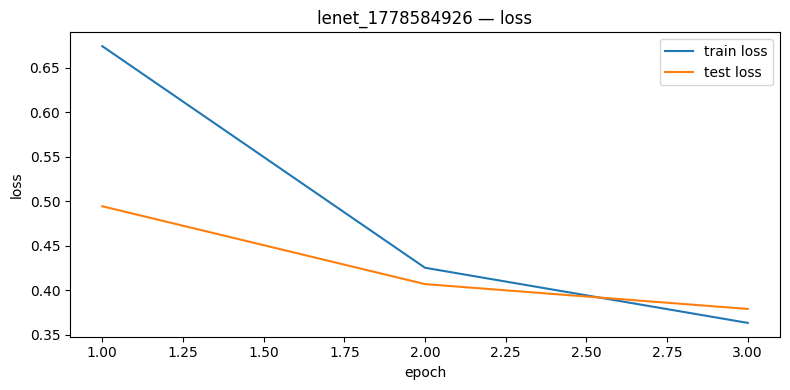

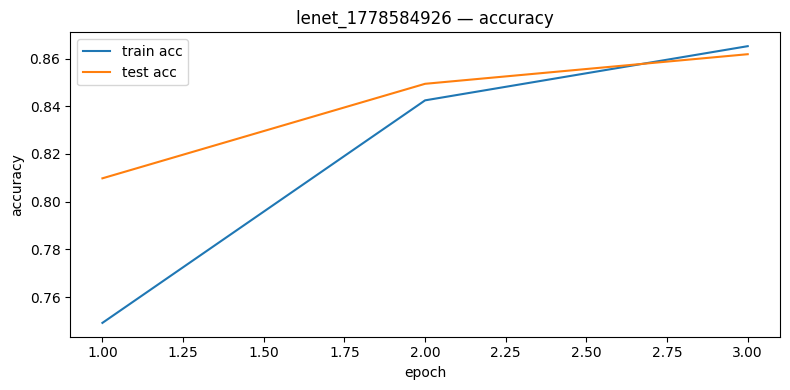

Saved: /home/ruhama/Desktop/YOLO/runs/figures/lenet_1778584926/curves_loss.png
Saved: /home/ruhama/Desktop/YOLO/runs/figures/lenet_1778584926/curves_acc.png


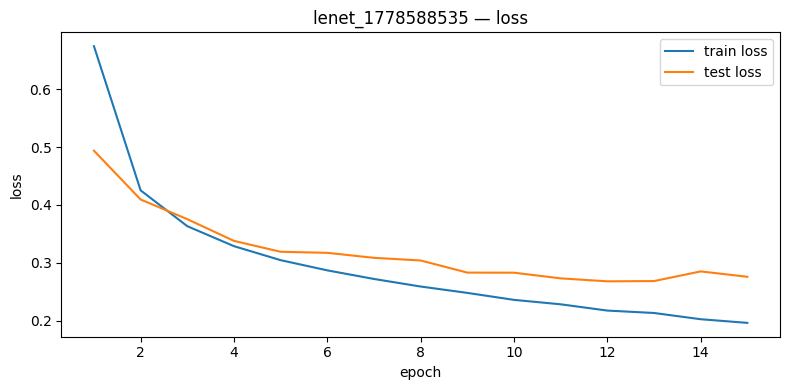

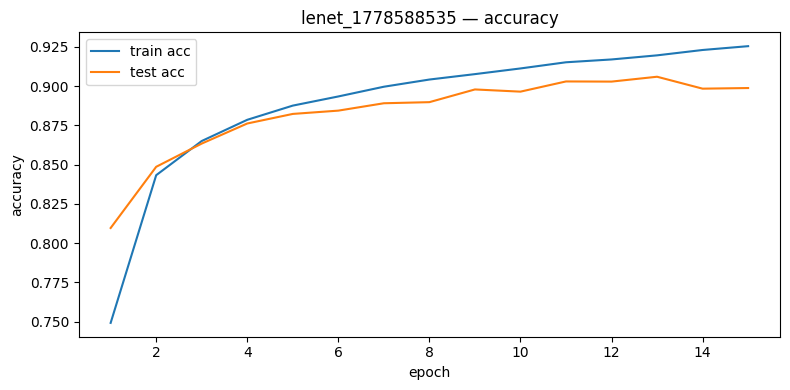

Saved: /home/ruhama/Desktop/YOLO/runs/figures/lenet_1778588535/curves_loss.png
Saved: /home/ruhama/Desktop/YOLO/runs/figures/lenet_1778588535/curves_acc.png
Figures directory: /home/ruhama/Desktop/YOLO/runs/figures


In [5]:
%matplotlib inline
# =============================================================================
# Plots — read metrics.jsonl from each LeNet run and save loss/accuracy curves as PNGs.
# =============================================================================
import matplotlib.pyplot as plt


FIG_DIR = RUN_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)


def load_jsonl(path):
    """Read a JSON-lines file produced by the training cell (one metric dict per line)."""
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))
    return rows


def plot_lenet_run(rows, out_base, title):
    """Plot train vs test loss, then train vs test accuracy; save under FIG_DIR/<run>/"""
    ep = [r["epoch"] for r in rows]
    # Loss plot: both curves on one axis to spot overfitting (train ↓ test ↑ gap).
    plt.figure(figsize=(8, 4))
    plt.plot(ep, [r["train_loss"] for r in rows], label="train loss")
    plt.plot(ep, [r["test_loss"] for r in rows], label="test loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(f"{title} — loss")
    plt.legend()
    plt.tight_layout()
    loss_path = out_base.with_name(out_base.stem + "_loss.png")
    plt.savefig(loss_path, dpi=160)
    plt.show()
    plt.close()

    # Accuracy plot: should trend upward if training is healthy.
    plt.figure(figsize=(8, 4))
    plt.plot(ep, [r["train_acc"] for r in rows], label="train acc")
    plt.plot(ep, [r["test_acc"] for r in rows], label="test acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(f"{title} — accuracy")
    plt.legend()
    plt.tight_layout()
    acc_path = out_base.with_name(out_base.stem + "_acc.png")
    plt.savefig(acc_path, dpi=160)
    plt.show()
    plt.close()
    print("Saved:", loss_path)
    print("Saved:", acc_path)


# Every run folder `lenet_<timestamp>/` should contain metrics.jsonl if training finished.
metrics_files = sorted(RUN_DIR.glob("lenet_*/metrics.jsonl"))
if not metrics_files:
    print("No lenet metrics.jsonl under RUN_DIR. Run training first.")
else:
    for mf in metrics_files:
        rows = load_jsonl(mf)
        if not rows:
            continue
        # Sanity filter: skip files missing the keys this notebook writes.
        if not {"train_acc", "test_acc"}.issubset(rows[0].keys()):
            continue
        run_name = mf.parent.name
        out_base = FIG_DIR / run_name / "curves"
        out_base.parent.mkdir(parents=True, exist_ok=True)
        plot_lenet_run(rows, out_base, title=run_name)
    print("Figures directory:", FIG_DIR)
